# MD Simulations of Solid and Liquid Phases of Cu
This notebook performs molecular dynamics (MD) simulations for both solid and liquid phases of copper (Cu). The generated structures are used to construct solid-liquid coexisting systems for further analysis. In addition, local order parameters are tested to distinguish between solid and liquid regions within the simulated structures.

**Workflow:**
1. Prepare and run MD simulations for solid and liquid phases.
2. Analyze the resulting trajectories and extract relevant structural and thermodynamic properties.
3. Use local order parameters to identify and visualize solid and liquid regions.
4. Export structures for use in coexisting phase simulations.

In [2]:
from pathlib import Path
from copy import deepcopy
from dataclasses import replace
from sklearn.calibration import delayed
import numpy as np
import pandas as pd
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt
from ase.io import read, write, Trajectory
from ase import Atoms, units
from ase.constraints import FixAtoms
from ase.calculators.emt import EMT
from ase.build import stack, bulk
from ase.visualize import view
from ase.optimize import LBFGS
from joblib import Parallel, delayed
import json

# Import from refactored md_simulation package
from md_simulation import (
    # Core functionality
    MDSimulationParams,
    run_md,
    # Structure tools
    opt_atoms,
    standardize_atoms,
    build_supercell,
    get_expand_cell_func,
    classify_solid_atoms,
)
from md_simulation.structure.analysis import calculate_bulk_modulus, get_solid_prob
from md_simulation.utils.io import read_yaml

from pyscal3 import System
from pfcc_extras.visualize import view_ngl
from pfcc_extras.structure.connectivity import get_neighbors

MODEL_VERSION = "v7.0.0"
CALC_MODE = 'PBE_PLUS_D3'

def get_calculator(model_version=MODEL_VERSION, calc_mode=CALC_MODE):
    """
    Returns an ASE calculator for the given model version and calculation mode.
    """
    calculator = EMT()
    # if isinstance(calc_mode, str):
    #     calc_mode = getattr(EstimatorCalcMode, calc_mode)
    # estimator = Estimator(model_version=model_version, calc_mode=calc_mode)
    # calculator = ASECalculator(estimator)
    return calculator

## Setup and Initialization
Import required libraries and set up the simulation environment. Define parameters for the MD simulations, such as temperature, pressure, and simulation cell size.

In [3]:
cwd = Path('.')
inputdir = cwd / 'input'
outputdir = cwd / 'output'
for _dir in (inputdir, outputdir):
    _dir.mkdir(exist_ok=True, parents=True)

In [5]:
# Settings
md_conf = inputdir / "md.yaml"
geometry_filename = inputdir / "POSCAR"
factor_temp_melt = 1.1

settings = read_yaml(md_conf) if md_conf.exists() else dict()
md_conf = {k:v for k,v in settings.items() if hasattr(MDSimulationParams, k)}
print(settings)
print(md_conf)
#atoms = read(geometry_filename)
atoms = bulk('Cu', cubic=True)
view_ngl(atoms)


{'num_samples': 5, 'num_steps': 10000, 'temperature': 800, 'temperatures': [800, 1000, 1200, 1400, 1600, 1800], 'timestep': 2.0, 'temperatures_coex': [800, 1000, 1200, 1400, 1600]}
{'num_steps': 10000, 'temperature': 800, 'temperatures': [800, 1000, 1200, 1400, 1600, 1800], 'timestep': 2.0}


## MD Simulation of Solid Phase
Run MD simulations for the solid phase of Cu. Analyze the resulting trajectory to extract properties such as temperature, energy, and structure. Visualize the atomic configuration to confirm the solid state.

In [6]:
params_base = MDSimulationParams(
    get_calculator=get_calculator,
    num_steps=10000,
    timestep=2.0,
    temperature=800,
    temperatures=(800, 1000, 1200, 1400, 1600, 1800),
    temp_begin=800,
    temp_end=1800,
    pressure=1.0,  # bar
    taut=500,
    taup=500,
    compressibility=1.0,
    logger="mdlogger.log",
    ensemble="npt",
    traj_interval=100,
    loginterval=100,
    logger_interval=100,
    overwrite=False,
    attach_functions=None,
)

params = replace(params_base, **md_conf)
params

MDSimulationParams(get_calculator=<function get_calculator at 0x31a6ac360>, num_steps=10000, timestep=2.0, temperature=800, temperatures=[800, 1000, 1200, 1400, 1600, 1800], temp_begin=800, temp_end=1800, pfactor=2000000.0, ttime=20.0, pressure=1.0, taut=500, taup=500, compressibility=1.0, fixcm=True, mask=(1, 1, 1), trajfile=None, logfile=None, logger='mdlogger.log', loginterval=100, traj_interval=100, logger_interval=100, ensemble='npt', overwrite=False, check_density=True, attach_functions=None)

In [7]:
# Optimize and standardize structure
atoms_opt = opt_atoms(atoms, get_calculator, fmax=0.01)
atoms_std = standardize_atoms(atoms_opt)
view(atoms_std, viewer="x3d")

       Step     Time          Energy          fmax
LBFGS:    0 18:58:45       -0.022726        0.160183
LBFGS:    1 18:58:45       -0.023771        0.144107
LBFGS:    2 18:58:45       -0.028144        0.002800


In [8]:
# Build supercell
cell_length = 10
repeat = np.ceil(cell_length / atoms_std.cell.lengths()).astype(int)
solid = build_supercell(atoms_std, repeat=repeat)
print(repeat)
print(atoms_std.cell)
print(solid.cell)
view(solid, viewer="x3d")

[3 3 3]
Cell([3.5894805688459575, 3.5894805688459575, 3.5894805688459575])
Cell([10.768441706537873, 10.768441706537873, 10.768441706537873])


       Step     Time          Energy          fmax
LBFGS:    0 18:58:46        5.536458        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 18:58:47        2.907758        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 18:58:47        1.043535        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 18:58:47       -0.131648        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 18:58:47       -0.690493        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 18:58:47       -0.699715        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 18:58:47       -0.219385        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 18:58:47        0.696853        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 18:58:47        2.001453        0.000000
       Step     Time          Energy          fmax
LBFGS:    0 1

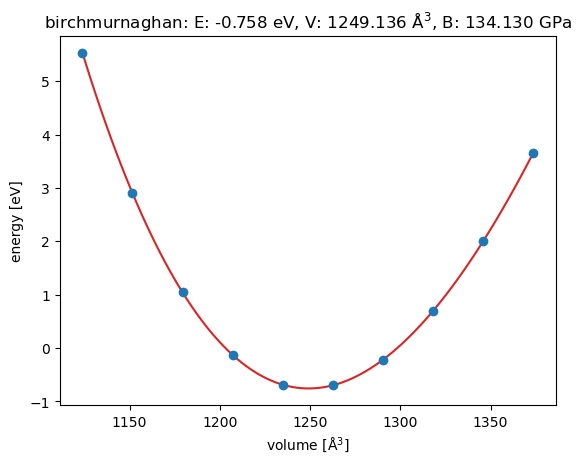

1249.1363950920127 -0.75820960880997 134.13014083478117


In [9]:
volume_ratio_lim = [0.9, 1.1]
num_data_points = 10
eosfile = outputdir / 'eos.json'
if eosfile.exists():
    with open(eosfile) as f:
        eos_parameters = json.load(f)
    B = eos_parameters['B']
    V0 = eos_parameters['v0']
    E0 = eos_parameters['e0']
else:
    V0, E0, B, eos = calculate_bulk_modulus(solid, volume_ratio_lim, get_calculator, num_data_points, return_eos=True)
    
    keys = ['B', 'v0', 'v', 'e0', 'e', 'eos_string']
    eos_parameters = {k:getattr(eos, k) for k in keys}
    eos_parameters = {k:list(v) if isinstance(v, np.ndarray) else v for k,v in eos_parameters.items()}
    with open(eosfile, 'w') as f:
        json.dump(eos_parameters, f)

    eos.plot(outputdir/'eos.png', show=True)

print(V0, E0, B)


In [10]:
# Run solid MD and get volumes
params_solid_equil = deepcopy(params)
params_solid_equil.num_steps = 5000
params_solid_equil.trajfile = f"solid_{params_solid_equil.temperature}K.traj"
params_solid_equil.logfile = f"solid_{params_solid_equil.temperature}K.log"
params_solid_equil.temp_begin = params_solid_equil.temp_end = None
solid_equilib, params_solid_equil = run_md(solid, params_solid_equil)

solid_equilib.write(outputdir/'solid_equilib.json')

print(solid_equilib)
print(solid_equilib.get_temperature())

Atoms(symbols='Cu108', pbc=True, cell=[10.962300993130974, 10.98883714298432, 10.931668736710545], momenta=..., calculator=SinglePointCalculator(...))
759.1463964901393


In [11]:
traj = Trajectory(params_solid_equil.trajfile)
xyzfile = Path(params_solid_equil.trajfile).with_suffix(".xyz")
if not xyzfile.exists():
    write(xyzfile, traj)

## Order Parameter Analysis: Identifying Solid and Liquid Regions
Test and visualize local order parameters (e.g., Steinhardt parameters) to distinguish between solid and liquid regions in the simulated structures. This analysis helps validate the phase of each region and is essential for constructing coexisting structures.

In [12]:
# def classify_solid_atoms(
#     atoms,
#     cutoff='adaptive',
#     cutoff_threshold=2.0,
#     padding=1.2,
#     q=6,
#     threshold=0.5,
#     avgthreshold=0.6,
#     cluster=True,
#     method='pyscal3',
# #    **kwargs
# ):
#     """
#     Identify solid atoms in the given ASE Atoms object using a chosen classification method.

#     Parameters:
#         atoms: ASE Atoms object.
#         cutoff: Cutoff method for neighbor finding ('adaptive', 'sann', or float).
#         bonds: Number of bonds required to be considered solid.
#         threshold: Local order parameter threshold.
#         avgthreshold: Average order parameter threshold.
#         cluster: Whether to use clustering for solid detection.
#         method: Classification method ('pyscal3', 'other').
#         **kwargs: Additional arguments for future methods.

#     Returns:
#         List of boolean values indicating whether each atom is solid.
#     """
#     if method == 'pyscal3':
#         pcsys = System()
#         pcsys.read.file(atoms, 'ase')
#         #pcsys.show.all(radius=4)

#         try:
#             pcsys.find.neighbors(method='cutoff', cutoff=cutoff, threshold=cutoff_threshold, padding=padding)
#         except RuntimeError as p:
#             print(f"Neighbor finding failed with cutoff={cutoff}, falling back to 'sann'. Exception: {p}")
#             pcsys.find.neighbors(method='cutoff', cutoff='sann')

#         cuttoffs = pcsys.atoms.neighbors.cutoff

#         n = pcsys.find.solids(q=q, threshold=threshold, avgthreshold=avgthreshold, cluster=cluster)

# #        pcsys.show.boolean_property(pcsys.atoms.solid)
#         return pcsys.atoms.solid
#     elif method == 'other':
#         # Placeholder for future alternative classification packages
#         # Example: return other_package.classify_solids(atoms, **kwargs)
#         raise NotImplementedError("Alternative solid classification method not implemented yet.")
#     else:
#         raise ValueError(f"Unknown classification method: {method}")


In [13]:
# Note: get_solid_prob function is now imported from md_simulation.structure.analysis

In [14]:
solid_prob_list = np.array([get_solid_prob(t, q=6) for t in traj])

[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
0.9907407407407407


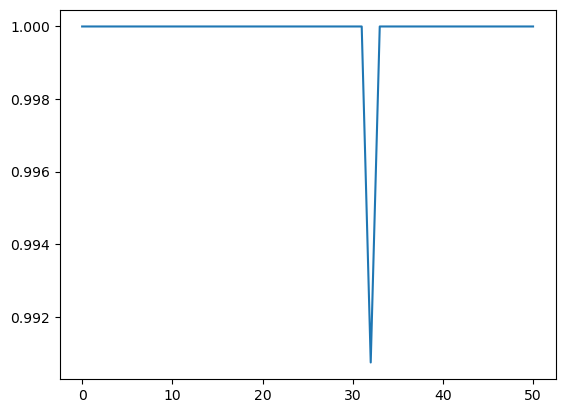

In [15]:
plt.plot(solid_prob_list.mean(axis=1))
solid_prob_threshold = np.min(solid_prob_list.mean(axis=1))
print(solid_prob_list)
print(solid_prob_threshold)
view_ngl(traj, replace_structure=True)

In [16]:
params

MDSimulationParams(get_calculator=<function get_calculator at 0x31a6ac360>, num_steps=10000, timestep=2.0, temperature=800, temperatures=[800, 1000, 1200, 1400, 1600, 1800], temp_begin=800, temp_end=1800, pfactor=2000000.0, ttime=20.0, pressure=1.0, taut=500, taup=500, compressibility=1.0, fixcm=True, mask=(1, 1, 1), trajfile=None, logfile=None, logger='mdlogger.log', loginterval=100, traj_interval=100, logger_interval=100, ensemble='npt', overwrite=False, check_density=True, attach_functions=None)

## NPT MD to estimate the melting temperature by increasing the temperature.

In [17]:
params_solid_anneal = deepcopy(params)
#temperatures = settings.get("temperatures")
#params_solid_anneal.temp_begin = settings.get("temperatures")[0]
#params_solid_anneal.temp_end = settings.get("temperatures")[-1]
params_solid_anneal.num_steps = 25_000
params_solid_anneal.trajfile = f"solid_{params_solid_anneal.temp_begin}K_{params_solid_anneal.temp_end}K.traj"
params_solid_anneal.logfile = f"solid_{params_solid_anneal.temp_begin}K_{params_solid_anneal.temp_end}K.log"
params_solid_anneal.compressibility = 1.0 / B  # in 1/GPa

In [18]:
print(params_solid_anneal)
atoms, params_solid_anneal = run_md(solid_equilib, params_solid_anneal)

MDSimulationParams(get_calculator=<function get_calculator at 0x31a6ac360>, num_steps=25000, timestep=2.0, temperature=800, temperatures=[800, 1000, 1200, 1400, 1600, 1800], temp_begin=800, temp_end=1800, pfactor=2000000.0, ttime=20.0, pressure=1.0, taut=500, taup=500, compressibility=0.0074554458362328865, fixcm=True, mask=(1, 1, 1), trajfile='solid_800K_1800K.traj', logfile='solid_800K_1800K.log', logger='mdlogger.log', loginterval=100, traj_interval=100, logger_interval=100, ensemble='npt', overwrite=False, check_density=True, attach_functions=None)


In [19]:
print(params_solid_anneal.trajfile)
traj = Trajectory(params_solid_anneal.trajfile)
atoms = traj[-1]

print(atoms.get_temperature())
print(atoms.get_stress())

solid_prob = get_solid_prob(atoms, q=6)
print(solid_prob.mean())
print(solid_prob)
view_ngl(traj, replace_structure=True)

solid_800K_1800K.traj
1837.911346573995
[ 0.00455012  0.01373965  0.00784774 -0.00920642 -0.00114111  0.0080622 ]
0.009259259259259259
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [20]:

for label, atoms in zip(('initial', 'final'), (traj[0], traj[-1])):
    print(label)
    pcsys = System()
    pcsys.read.file(atoms, 'ase')
    pcsys.show.all(radius=12)
    for method, cutoff in (('cutoff', 'adaptive'), ('cutoff', 'sann'), ('voronoi', '')):
        if method[0]=='c':
            pcsys.find.neighbors(method=method, cutoff=cutoff)
        else: 
            pcsys.find.neighbors(method=method)
        for i in (4, 6, 8, 12):
            print(method, cutoff, i, f'{pcsys.find.solids(q=i)} {np.mean(pcsys.atoms.solid):.4f}') 

print(dir(pcsys))

initial


cutoff adaptive 4 108 1.0000
cutoff adaptive 6 108 1.0000
cutoff adaptive 8 108 1.0000
cutoff adaptive 12 107 0.9907
cutoff sann 4 2 0.1296
cutoff sann 6 108 1.0000
cutoff sann 8 108 1.0000
cutoff sann 12 108 1.0000
voronoi  4 1 1.0000
voronoi  6 1 1.0000
voronoi  8 1 1.0000
voronoi  12 1 0.9815
final


cutoff adaptive 4 0 0.0000
cutoff adaptive 6 1 0.0093
cutoff adaptive 8 0 0.0000
cutoff adaptive 12 0 0.0000
cutoff sann 4 0 0.0000
cutoff sann 6 0 0.0000
cutoff sann 8 0 0.0000
cutoff sann 12 0 0.0000
voronoi  4 0 0.0000
voronoi  6 0 0.0000
voronoi  8 0 0.0000
voronoi  12 0 0.0000
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_atoms', '_box', '_check_neighbors', '_refresh_internal_methods', '_structure_dict', 'actual_box', 'add_atoms', 'analyze', 'apply_selection', 'atoms', 'box', 'box_dimensions', 'boxdims', 'calculate', 'chemical', 'composition', 'concentration', 'convert_to', 'create', 'delete', 'direct_coordinates', 'filter', 'find', 'ghosts_created', 'initialized', 'int

### Visualize and Interpret Order Parameter Results
Visualize the distribution of the order parameter for both solid and liquid phases. Use this information to set thresholds for distinguishing solid and liquid regions, and validate the effectiveness of the order parameter in phase identification.

251 (251, 108) 2
250 (250, 3, 3) (250, 108, 3)


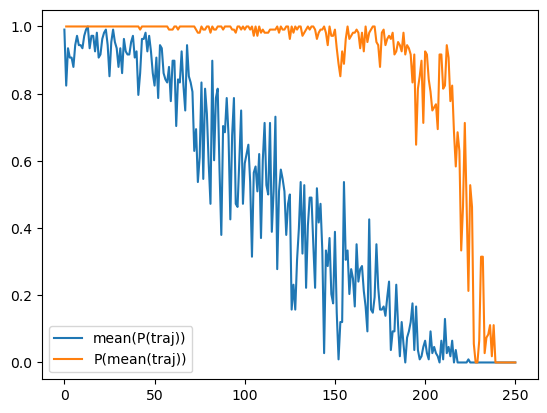

[0. 1.]


In [21]:
window = int(params.taut / (params.timestep * params.traj_interval))

pos = np.array([t.positions for t in traj])
#pos_mean = np.convolve(pos, params.taut, 'same')
cells = np.array([t.cell.array for t in traj])
#cell_mean = np.convole(cell, params.taut, 'same', axis=0)

pos_mean = fftconvolve(pos, np.ones((window, 1, 1))/window, 'valid', axes=0)
cell_mean = fftconvolve(cells, np.ones((window, 1, 1))/window, 'valid', axes=0)

num_data = len(traj) - window + 1
shift = int(0.5*window)
slice_valid = slice(shift, num_data+shift)

atoms_list = [Atoms(cell=c, positions=p, numbers=atoms.numbers, pbc=True) for c,p in zip(cell_mean, pos_mean)]
for a in atoms_list:
    a.wrap()

solid_prob_list_mean = np.array([get_solid_prob(a, q=12) for a in atoms_list])
solid_prob_list_mean = np.array([get_solid_prob(Atoms(cell=c, positions=p, numbers=atoms.numbers, pbc=True), q=12) for c,p in zip(cell_mean, pos_mean)])
solid_prob_list = np.array([get_solid_prob(t, q=12) for t in traj])

print(len(traj), solid_prob_list.shape, window)
print(num_data, cell_mean.shape, pos_mean.shape)
plt.plot([np.mean(p) for p in solid_prob_list], label='mean(P(traj))')  
plt.plot(np.arange(slice_valid.start, slice_valid.stop), [np.mean(p) for p in solid_prob_list_mean], label='P(mean(traj))')
plt.legend()
plt.show()
print(np.unique(solid_prob_list))

In [22]:
solid_prob_threshold = 0.85
melt_prob_threshold = 0.1
atoms_mean = Atoms(cell=cell_mean[-1], positions=pos_mean[-1], numbers=atoms.numbers, pbc=1)

#mask_solid = np.zeros_like(temperatures, dtype=bool)
#mask_melt = np.zeros_like(temperatures, dtype=bool)
mask_solid = np.zeros(len(traj), dtype=bool)
mask_melt = np.zeros(len(traj), dtype=bool)

mask_solid[slice_valid.start:slice_valid.stop] = np.array([np.mean(p) > solid_prob_threshold for p in solid_prob_list_mean], dtype=bool)
mask_solid[slice_valid.stop:] = mask_solid[slice_valid.stop-1]

mask_melt[slice_valid.start:slice_valid.stop] = np.array([np.mean(p) < melt_prob_threshold for p in solid_prob_list_mean], dtype=bool)
mask_melt[slice_valid.stop:] = mask_melt[slice_valid.stop-1]

index_melt = np.where(mask_melt)[0][0]
print(index_melt)
print(mask_solid)
print(mask_melt)
view_ngl([traj[-1], traj[index_melt], Atoms(cell=cell_mean[-1], positions=pos_mean[-1], numbers=atoms.numbers, pbc=1)], replace_structure=True)

227
[False  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  Tru

In [23]:
temperatures = np.array([t.get_temperature() for t in traj])
volumes = np.array([t.get_volume() for t in traj])

In [24]:
csvfile = outputdir/f'solid_{params_solid_anneal.temp_begin}K_{params_solid_anneal.temp_end}K.csv'
temperatures = np.array([t.get_temperature() for t in traj])
volumes = np.array([t.get_volume() for t in traj])
volumes_per_atom = np.array([t.get_volume()/len(t) for t in traj])
cellpar = np.array([t.cell.cellpar() for t in traj])
data = np.array([temperatures, volumes]).T
keys = ['T', 'V', 'volume_per_atom', 'a', 'b','c', 'alpha', 'beta', 'gamma', 'solid', 'melt']
df = pd.DataFrame([temperatures, volumes, volumes_per_atom, *cellpar.T, mask_solid, mask_melt], index=keys).T
print(csvfile)
display(df)
df.to_csv(csvfile)

output/solid_800K_1800K.csv


,T,V,volume_per_atom,a,b,c,alpha,beta,gamma,solid,melt
0,885.66685,1453.51702,13.458491,11.329092,11.356517,11.297435,90.0,90.0,90.0,False,False
1,766.354401,1422.375411,13.170143,11.249022,11.27398,11.215592,90.0,90.0,90.0,True,False
2,799.255545,1398.086929,12.945249,11.186734,11.209925,11.148801,90.0,90.0,90.0,True,False
3,891.329097,1379.411016,12.772324,11.13848,11.157879,11.099058,90.0,90.0,90.0,True,False
4,789.240404,1365.539227,12.643882,11.101548,11.119526,11.062018,90.0,90.0,90.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...
246,1569.828162,1529.568456,14.162671,11.618787,11.470438,11.476993,90.0,90.0,90.0,False,True
247,1627.450415,1532.436252,14.189225,11.634147,11.476725,11.47704,90.0,90.0,90.0,False,True
248,1701.961347,1535.292263,14.215669,11.647185,11.482157,11.480125,90.0,90.0,90.0,False,True
249,1729.482745,1540.279621,14.261848,11.662058,11.491531,11.493345,90.0,90.0,90.0,False,True


Atoms(symbols='Cu108', pbc=True, cell=[10.962300993130974, 10.98883714298432, 10.931668736710545], momenta=..., calculator=SinglePointCalculator(...))
201
201


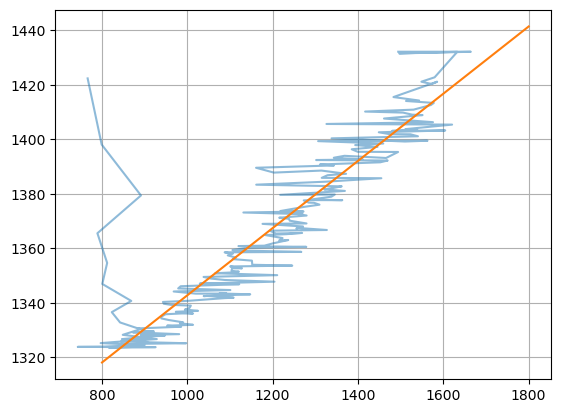

In [28]:
#temperatures_solid = np.array([t.get_temperature() for t in traj])[:index_melt]
#volumes_solid = np.array([t.get_volume() for t in traj])[:index_melt]
csvfile = outputdir/f'solid_{params_solid_anneal.temp_begin}K_{params_solid_anneal.temp_end}K.csv'
df = pd.read_csv(csvfile)

solid_equilib = read(outputdir/'solid_equilib.json')
temperatures = df['T']
volumes = df['V']
temperatures_solid = temperatures[df['solid']].values
volumes_solid = volumes[df['solid']].values
print(solid_equilib)
plt.plot(temperatures_solid, volumes_solid, alpha=0.5)

window = 2 * int(params.taut / (params.timestep * params.traj_interval))
step = window // 5 if window > 5 else 1
expand_cell = get_expand_cell_func(len(solid_equilib), temperatures_solid, volumes_solid, window=window, step=step)

plt.plot((params.temp_begin, params.temp_end), [expand_cell(solid_equilib, t).get_volume() for t in (params.temp_begin, params.temp_end)])
plt.grid()

print(len(temperatures_solid))
print(len(volumes_solid))

In [29]:
melt = traj[-1]
melt.set_tags(1)
melt.write(outputdir/"melt.json")

melt_temp = temperatures[mask_melt].min()
print(melt_temp)
view_ngl(melt)

1514.7887477622826


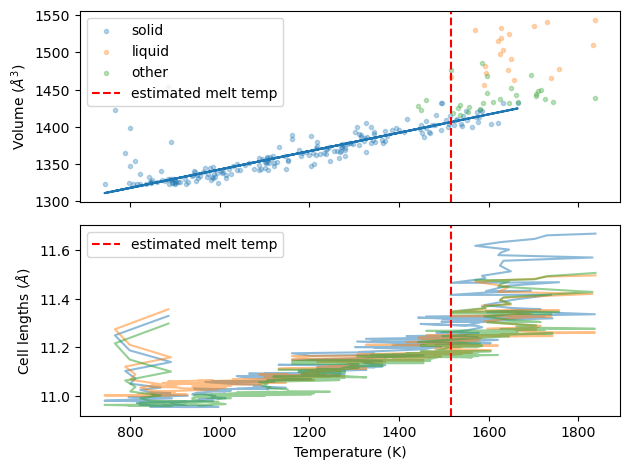

In [30]:
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
atoms_list = [expand_cell(solid_equilib.copy(), t) for t in temperatures_solid]
ax0.scatter(temperatures_solid, volumes_solid, marker=".", alpha=0.3, label='solid')
ax0.scatter(temperatures[mask_melt], volumes[mask_melt], marker=".", alpha=0.3, label='liquid')
ax0.scatter(temperatures[~mask_melt & ~mask_solid], volumes[~mask_melt & ~mask_solid], marker=".", alpha=0.3, label='other')
ax0.plot(temperatures_solid, [a.get_volume() for a in atoms_list], marker="")
ax0.axvline(melt_temp, color='red', linestyle='--', label='estimated melt temp')
ax0.set_ylabel("Volume ($\AA^3$)")
#ax0.set_xlabel("Temperature (K)")
ax0.legend()
ax1.plot(temperatures, [a.cell.lengths() for a in traj], alpha=0.5)
ax1.set_ylabel("Cell lengths ($\AA$)")
ax1.set_xlabel("Temperature (K)")
ax1.axvline(melt_temp, color='red', linestyle='--', label='estimated melt temp')
ax1.legend()
plt.tight_layout()
plt.show()

## Summary and Next Steps
- MD simulations for both solid and liquid phases of Cu were performed and analyzed.
- Local order parameters were tested and validated for distinguishing solid and liquid regions.
- The resulting structures and analysis will be used to construct and study solid-liquid coexisting systems in subsequent notebooks.